# UPI Behavioral Embeddings (BFS v1)
This notebook demonstrates the unsupervised Representation Learning pipeline for UPI transaction data.

It extracts Cashflow, Behavioral, Entropy, and Graph features to build a unified `feature_store.parquet`, runs statistical audits, and generates final behavioral clusters using PCA and UMAP.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../bfs'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

from cashflow_engine import extract_cashflow_features
from behavioral_features import extract_behavioral_features
from entropy_features import extract_entropy_features
from graph_features import extract_graph_features
from behavior_embeddings import audit_features

## 1. Load Raw Transactions
We start by loading the 20,000 raw UPI transactions.

In [2]:
data_dir = "../dummtdatasets/upi"
tx_df = pd.read_csv(os.path.join(data_dir, "transactions.csv"))
print(f"Loaded {len(tx_df)} transactions.")
tx_df.head()

Loaded 20000 transactions.


,transaction_id,user_id,receiver_id,receiver_type,amount,timestamp,date,hour_of_day,day_of_week,is_weekend,...,user_loyalty_score,new_device_flag,ip_location_mismatch,failed_attempts_last_24h,transaction_velocity,amount_deviation_score,is_fraud,recurring_payment_flag,balance_after_transaction,transaction_frequency_score
0,TXN0013171,USR01949,MRC0069,Merchant,1533.88,2024-01-01 00:21:17,2024-01-01,0,Monday,0,...,0.194,0,0,2,0.0,2.2467,0,1,36023.96,0.72
1,TXN0006480,USR01975,MRC0048,Merchant,1371.57,2024-01-01 00:36:29,2024-01-01,0,Monday,0,...,0.213,0,0,0,4.0,1.1773,0,0,65138.89,0.68
2,TXN0001430,USR01127,MRC0312,Merchant,500.50,2024-01-01 00:47:46,2024-01-01,0,Monday,0,...,0.381,0,0,0,1.0,0.1471,0,1,69347.11,0.86
3,TXN0003501,USR00827,USR01877,User,724.05,2024-01-01 00:52:07,2024-01-01,0,Monday,0,...,0.238,0,0,1,0.0,1.6019,0,0,52305.43,1.00
4,TXN0004423,USR00673,USR00534,User,128.22,2024-01-01 01:22:31,2024-01-01,1,Monday,0,...,0.187,0,0,5,1.0,0.3076,0,0,9601.13,0.48


## 2. Feature Extraction Engines
We process the raw transactions through our 4 specialized engines to build $B(X)$.

In [3]:
print("Extracting Cashflow Features...")
cf = extract_cashflow_features(tx_df)

print("Extracting Behavioral Features...")
beh = extract_behavioral_features(tx_df)

print("Extracting Entropy Features...")
ent = extract_entropy_features(tx_df)

print("Extracting Graph Features...")
graph = extract_graph_features(tx_df)

# Merge into a single DataFrame
df = cf.merge(beh, on='user_id').merge(ent, on='user_id').merge(graph, on='user_id')
print(f"\nFeature Store Shape: {df.shape}")
display(df.head())

Extracting Cashflow Features...
Extracting Behavioral Features...
Extracting Entropy Features...
Extracting Graph Features...

Feature Store Shape: (2000, 16)


,user_id,ips_score,cash_burn_30d,savings_ratio,buffer_capacity,velocity,spending_volatility,weekend_ratio,spending_concentration,merchant_churn_30d,recurrence_score,merchant_entropy,category_entropy,temporal_entropy,degree_centrality,pagerank
0,USR00001,0.351715,0.512613,-0.495496,3.435424,0.031884,867.503898,0.250898,0.315544,1.0,0.00,2.397895,1.342113,2.019815,0.006253,0.000377
1,USR00002,0.055259,0.664461,0.420861,5.495448,0.034146,216.507985,0.109301,0.197170,1.0,0.00,1.945910,0.955700,1.747868,0.004168,0.000273
2,USR00003,0.000000,0.000000,0.014661,2.026118,0.041451,434.822768,0.709544,0.452867,1.0,0.25,1.906155,1.082196,1.732868,0.003752,0.000266
3,USR00004,0.394950,0.000000,0.383952,4.805445,0.032895,157.610022,0.000000,0.242811,1.0,0.00,2.302585,1.609438,1.748067,0.006253,0.000382
4,USR00005,0.000000,0.000000,0.064319,5.822005,0.025000,638.775913,0.154525,0.264567,1.0,0.00,2.079442,1.073543,2.079442,0.003752,0.000254


## 3. Auditing (Missingness, Correlation, Stability)
Before saving the feature store, we must ensure it is structurally sound.

In [4]:
to_drop = audit_features(df)
if to_drop:
    df.drop(columns=to_drop, inplace=True, errors='ignore')

--- 1. Missingness Report ---
Series([], dtype: float64)
No missing values found!

--- 2. Correlation Audit ---
Highly correlated features to drop (>0.95): ['pagerank']

--- 3. Stability Report (Bootstrapping Variance) ---
buffer_capacity     0.361530
recurrence_score    0.085046
cash_burn_30d       0.038107
ips_score           0.021516
velocity            0.010102
dtype: float64


## 4. Dimensionality Reduction (PCA)
We standardize the features and compress them into 10 principal components.

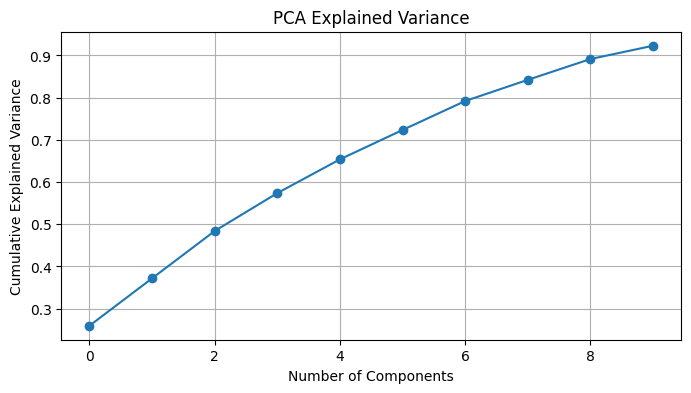

Total Variance Explained by 10 components: 0.9231


In [5]:
features = df.drop(columns=['user_id']).fillna(0)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

print(f"Total Variance Explained by 10 components: {np.sum(pca.explained_variance_ratio_):.4f}")

## 5. UMAP & Clustering
We use UMAP to visualize the latent behavioral space in 2D, and K-Means to assign distinct cluster archetypes.

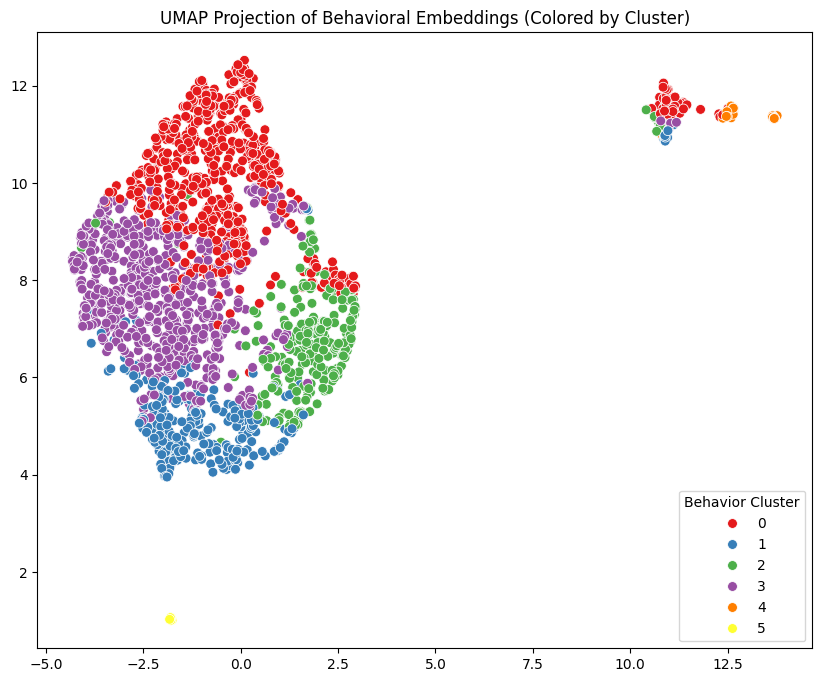

Cluster Distribution:


behavior_cluster_id
3    706
0    683
1    293
2    264
4     42
5     12
Name: count, dtype: int64

In [6]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_result = reducer.fit_transform(scaled_features)

kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(pca_result)
df['behavior_cluster_id'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(x=umap_result[:, 0], y=umap_result[:, 1], hue=clusters, palette='Set1', s=50)
plt.title('UMAP Projection of Behavioral Embeddings (Colored by Cluster)')
plt.legend(title='Behavior Cluster')
plt.show()

print("Cluster Distribution:")
display(df['behavior_cluster_id'].value_counts())